In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, List
import time

In [2]:
# =============================================================================
# QUATERNION ALGEBRA - COMPLETE OPERATIONS
# =============================================================================

def quaternion_product(p, q):
    """
    Quaternion Hamilton product p ⊗ q.

    For p = [pw, px, py, pz] and q = [qw, qx, qy, qz]:
    p ⊗ q = [pw*qw - pv·qv, pw*qv + qw*pv + pv×qv]

    Note: Non-commutative! p ⊗ q ≠ q ⊗ p
    """
    pw, px, py, pz = p[0], p[1], p[2], p[3]
    qw, qx, qy, qz = q[0], q[1], q[2], q[3]

    w = pw*qw - px*qx - py*qy - pz*qz
    x = pw*qx + px*qw + py*qz - pz*qy
    y = pw*qy - px*qz + py*qw + pz*qx
    z = pw*qz + px*qy - py*qx + pz*qw

    return np.array([w, x, y, z])


def quaternion_conjugate(q):
    """Quaternion conjugate q* = [qw, -qv]."""
    return np.array([q[0], -q[1], -q[2], -q[3]])


def quaternion_inverse(q):
    """Quaternion inverse q^(-1) = q* / ||q||²."""
    q_conj = quaternion_conjugate(q)
    norm_sq = np.sum(q**2)
    return q_conj / (norm_sq + 1e-12)


def quaternion_to_rotation_vector(q):
    """
    Log map S³ → ℝ³ (quaternion to rotation vector).

    For q = [cos(θ/2), sin(θ/2)·n]:
    log(q) = θ·n
    """
    qw, qv = q[0], q[1:4]
    qv_norm = np.linalg.norm(qv)

    if qv_norm < 1e-8:
        return 2.0 * qv

    theta = 2.0 * np.arctan2(qv_norm, qw)

    if np.abs(theta) < 1e-6:
        return 2.0 * qv

    return (theta / qv_norm) * qv


def rotation_vector_to_quaternion(theta_v):
    """
    Exp map ℝ³ → S³ (rotation vector to quaternion).

    For θ·n ∈ ℝ³:
    exp(θ·n) = [cos(θ/2), sin(θ/2)·n]
    """
    theta = np.linalg.norm(theta_v)

    if theta < 1e-8:
        return np.array([1.0, 0.5*theta_v[0], 0.5*theta_v[1], 0.5*theta_v[2]])

    half_theta = 0.5 * theta
    s = np.sin(half_theta) / theta

    return np.array([np.cos(half_theta), s*theta_v[0], s*theta_v[1], s*theta_v[2]])


def quaternion_boxplus(q, delta_theta):
    """
    Manifold ⊞ operator (right perturbation).

    q ⊞ δθ = q ⊗ exp(δθ)
    """
    delta_q = rotation_vector_to_quaternion(delta_theta)
    result = quaternion_product(q, delta_q)
    return result / (np.linalg.norm(result) + 1e-12)


def quaternion_boxminus(q1, q2):
    """
    Manifold ⊟ operator.

    q₁ ⊟ q₂ = log(q₂^(-1) ⊗ q₁)

    Returns rotation vector that takes q₂ to q₁.
    """
    q2_inv = quaternion_inverse(q2)
    q_diff = quaternion_product(q2_inv, q1)
    return quaternion_to_rotation_vector(q_diff)

def pmd_vector_to_quaternion(beta_vec, omega, omega_0):
    """
    Convert PMD vector beta to quaternion rotation at frequency omega.
    """
    delta_omega = omega - omega_0
    beta_mag = np.linalg.norm(beta_vec)

    if beta_mag < 1e-12:
        return Quaternion(1.0, 0.0, 0.0, 0.0)

    n = beta_vec / beta_mag
    theta = 0.5 * delta_omega * beta_mag

    w = np.cos(theta)
    xyz = n * np.sin(theta)

    return Quaternion(w, xyz[0], xyz[1], xyz[2])


# =============================================================================
# SPECTRAL FIDELITY COMPUTATION
# =============================================================================

def compute_spectral_fidelity(psi_in, psi_out):
    """
    Compute quantum state fidelity F = |⟨ψ_in|ψ_out⟩|².

    For quaternions: F = (q_in^T q_out)²
    """
    inner_product = np.dot(psi_in, psi_out)
    return np.abs(inner_product)**2


def compute_broadband_fidelity(psi_in, psi_out_freq, spectral_weights):
    """
    Compute spectrum-weighted average fidelity.

    F_total = Σᵢ Sᵢ F(λᵢ)
    """
    num_freq = psi_out_freq.shape[1]
    fidelities = np.zeros(num_freq)

    for i in range(num_freq):
        fidelities[i] = compute_spectral_fidelity(psi_in, psi_out_freq[:, i])

    return np.sum(spectral_weights * fidelities)


# =============================================================================
# QUATERNION CLASS
# =============================================================================

@dataclass
class Quaternion:
    """Quaternion representation for polarization states."""
    w: float  # Scalar part
    x: float  # Vector parts
    y: float
    z: float

    def normalize(self):
        """Normalize to unit quaternion."""
        norm = np.sqrt(self.w**2 + self.x**2 + self.y**2 + self.z**2)
        if norm > 0:
            self.w /= norm
            self.x /= norm
            self.y /= norm
            self.z /= norm
        return self

    def to_array(self):
        """Convert to numpy array."""
        return np.array([self.w, self.x, self.y, self.z])

    @classmethod
    def from_pmd_vector(cls, beta_vec):
        """
        Create quaternion from PMD vector β.

        β = [βx, βy, βz] represents PMD in Stokes space
        Quaternion: q = exp(β/2) = [cos(|β|/2), sin(|β|/2)·β/|β|]
        """
        beta_norm = np.linalg.norm(beta_vec)

        if beta_norm < 1e-10:
            return cls(1.0, 0.0, 0.0, 0.0)

        half_beta = beta_norm / 2.0
        w = np.cos(half_beta)
        xyz = np.sin(half_beta) * beta_vec / beta_norm

        return cls(w, xyz[0], xyz[1], xyz[2])

In [3]:
# =============================================================================
# QUANTUM CHANNEL
# =============================================================================
 
class QuantumChannel:
    """Quantum channel with PMD using quaternion representation and drift, with some improvements.
    1) drift_0 with an exponentially correclated process
    2) chromatic PMD contribution is random in all 3 dimensions
    3) normalize the PMD vector direction at the end"""

    def __init__(self, fiber_length_km=50, beta_0=0.1, beta_1=0.05, 
                 time_scale=1000, drift_gamma=0.01, seed=None,
                 beta_1_boost=5.0, beta_1_step_start=300, beta_1_step_len=50):
        self.fiber_length = fiber_length_km
        self.beta_0 = beta_0      # First-order PMD coefficient
        self.beta_1 = beta_1      # Second-order (chromatic) PMD coefficient
        self.time_scale = time_scale
        self.current_iteration = 0
        self.drift_gamma = drift_gamma

        # NEW CH CHANGE:4 Additional parameters for chromatic PMD boost (Step beta1 for a window of iterations)
        self.beta_1_base = float(beta_1)
        self.beta_1 = float(beta_1)  # keep existing
        self.beta_1_boost = float(beta_1_boost)
        self.beta_1_step_start = int(beta_1_step_start)
        self.beta_1_step_len = int(beta_1_step_len)
        
        # NEW CH CHANGE:3 Slow chromatic direction + occasional jumps
        # Chromatic PMD direction state (unit vector)
        self.chrom_dir = np.random.randn(3)
        self.chrom_dir /= np.linalg.norm(self.chrom_dir)
        # Tuning knobs
        self.chrom_dir_gamma = 0.01     # small => slowly varying
        self.chrom_dir_jump_p = 0.002   # probability of a direction jump per iteration


        if seed is not None:
            np.random.seed(seed)

        # Initialize random PMD vector direction
        self.base_pmd = np.random.randn(3)
        self.base_pmd = self.base_pmd / np.linalg.norm(self.base_pmd) * beta_0

        # DGD parameters (Gordon scaling) --> [OMAR] this need to be corrected with \sigma_0 = 0.085 
        #self.dgd_mean = 5e-12 * np.sqrt(fiber_length_km / 100.0)
        #self.dgd_std = 0.005 * self.dgd_mean
        self.dgd_std = 0.085e-12 * np.sqrt(fiber_length_km)

    def update(self, iteration):
        """Update channel state (slow time-varying PMD drift)."""
        self.current_iteration = iteration

        # NEW CH CHANGE:3 slowly varying chromatic direction + occasional jumps
        if np.random.rand() < self.chrom_dir_jump_p:
            d = np.random.randn(3)
        else:
            d = (1 - self.chrom_dir_gamma) * self.chrom_dir + self.chrom_dir_gamma * np.random.randn(3)
        self.chrom_dir = d / (np.linalg.norm(d) + 1e-12)

        # Correlated random walk for PMD vector drift
        drift_noise = np.random.randn(3)
        self.base_pmd = (1 - self.drift_gamma) * self.base_pmd + self.drift_gamma * drift_noise
        self.base_pmd = self.base_pmd / np.linalg.norm(self.base_pmd) * self.beta_0

        # NEW CH CHANGE:4 Update beta_1 for chromatic PMD boost (Step beta1 for a window of iterations)
        if self.beta_1_step_start <= iteration < (self.beta_1_step_start + self.beta_1_step_len):
            self.beta_1 = self.beta_1_base * self.beta_1_boost
        else:
            self.beta_1 = self.beta_1_base

        # NEW CH CHANGE:1 occasional step jump (regime change)
        if np.random.rand() < 0.002:          # e.g. p_jump = 0.002
            self.base_pmd = np.random.randn(3)
            self.base_pmd = self.base_pmd / np.linalg.norm(self.base_pmd) * self.beta_0

    def get_pmd_vector(self, omega):
        """
        Get PMD vector β(ω) = β₀ + β₁·(ω - ω₀), with smooth temporal drift and chromatic variation.
        """
        omega_0 = 2 * np.pi * 193.1e12  # Center frequency (C-band)
        delta_omega = (omega - omega_0) / omega_0  # Normalized frequency deviation

        # Temporal slow variation (sinusoidal modulation)
        time_factor = 1.0 + 0.1 * np.sin(2 * np.pi * self.current_iteration / self.time_scale)

        # Add correlated random walk noise to simulate slow fiber fluctuations
        drift_term = np.random.randn(3) * self.dgd_std * 0.1

        # # NEW CH CHANGE:2 burst noise
        if np.random.rand() < 0.01:          # p_burst = 0.01
            drift_term += np.random.randn(3) * 5 * self.dgd_std  # e.g. 5*self.dgdstd

        # Base PMD + temporal drift
        beta = self.base_pmd * time_factor + drift_term

        # Chromatic (frequency-dependent) PMD contribution
        # chromatic_rotation = self.beta_1 * delta_omega * np.random.randn(3)
        chromatic_rotation = self.beta_1 * delta_omega * self.chrom_dir  # NEW CH CHANGE:3 Slow chromatic direction + occasional jumps
        beta += chromatic_rotation

        # Normalize PMD vector (direction only matters)
        beta /= np.linalg.norm(beta)

        return beta

    def get_state(self, omega):
        """Get channel quaternion state at frequency ω (via axis-angle to quaternion)."""
        beta_vec = self.get_pmd_vector(omega)
        beta_mag = np.linalg.norm(beta_vec)
        axis = beta_vec / (beta_mag + 1e-12)
        theta = beta_mag  # small-angle approximation for PMD phase
        q = np.array([
            np.cos(theta / 2),
            *(np.sin(theta / 2) * axis)
        ])
        return Quaternion.from_pmd_vector(q)


In [4]:
# =============================================================================
# NLMS Quaternion-Regression ALGORITHM 
# =============================================================================

class QuantumNLMS:
    """
    Quaternion-regression NLMS (per-frequency, 3-DoF tangent-space update).

    Consistent with TrueQuaternionLMS/TrueQuaternionRLS:
      q_out = conj(q_comp) ⊗ q_channel
      nu    = boxminus(q_target, q_out)  (R^3 innovation)

    NLMS-style normalization: divide by input power (||q_channel||^2 + eps).
    (In this notebook q_channel is typically unit, so this behaves like LMS,
     but the normalization keeps the interface and stabilizes corner cases.)
    """

    def __init__(self,
                 stepsize=0.5,
                 numfreq=5,
                 eps=1e-12,
                 clamp_delta=0.5,
                 sign_invariant=True,
                 update_sign=-1.0):
        self.mu = float(stepsize)
        self.numfreq = int(numfreq)
        self.eps = float(eps)
        self.clamp_delta = float(clamp_delta)
        self.sign_invariant = bool(sign_invariant)
        self.update_sign = float(update_sign)

        # Compensator quaternions (4, numfreq), identity init
        self.qcomp = np.tile(np.array([1.0, 0.0, 0.0, 0.0])[:, None], (1, self.numfreq))

        # Keep "w" for compatibility with existing plotting/simulator returns
        self.w = self.qcomp.reshape(-1, 1)

        self.mse_history = []
        self.w_history = []
        self.spectral_fidelity_history = []
        self.error_norm_history = []

    def _normalize_target(self, target):
        if target.ndim == 1:
            return np.tile(target.reshape(4, 1), (1, self.numfreq))
        return target

    def adapt(self, x, target, spectralweights=None):
        """
        Args:
            x: channel quaternions, shape (4, numfreq)
            target: target quaternion(s), shape (4, numfreq) or (4,)
        """
        qtarget_all = self._normalize_target(target)

        total_mse = 0.0
        total_errnorm = 0.0

        for f in range(self.numfreq):
            qc = self.qcomp[:, f].copy()
            qch = x[:, f].copy()
            qtgt = qtarget_all[:, f].copy()

            # Compensated output
            qcconj = quaternion_conjugate(qc)
            qout = quaternion_product(qcconj, qch)
            qout = qout / (np.linalg.norm(qout) + self.eps)

            # Resolve q vs -q ambiguity against current output (rotation equivalence)
            if self.sign_invariant and (np.dot(qtgt, qout) < 0.0):
                qtgt = -qtgt

            # Innovation in tangent space (R^3)
            nu = quaternion_boxminus(qtgt, qout)  # shape (3,)

            # NLMS normalization by input power (||qch||^2 + eps)
            p = float(np.dot(qch, qch)) + self.eps

            # Gradient step in tangent space
            delta = (self.mu / p) * nu

            # Clamp large exp-map steps
            dn = np.linalg.norm(delta)
            if dn > self.clamp_delta:
                delta = delta * (self.clamp_delta / (dn + self.eps))

            # Apply multiplicative update on S^3
            self.qcomp[:, f] = quaternion_boxplus(qc, self.update_sign * delta)
            self.qcomp[:, f] = self.qcomp[:, f] / (np.linalg.norm(self.qcomp[:, f]) + self.eps)

            total_errnorm += float(np.linalg.norm(nu))
            total_mse += float(np.dot(nu, nu))

        avg_mse = total_mse / self.numfreq
        avg_err = total_errnorm / self.numfreq

        self.mse_history.append(avg_mse)
        self.error_norm_history.append(avg_err)

        # Compatibility
        self.w = self.qcomp.reshape(-1, 1)
        self.w_history.append(self.qcomp.flatten())

        # Spectral fidelity (same pattern as your other quaternion-regression filters)
        if spectralweights is not None:
            compensated = np.zeros((4, self.numfreq))
            for f in range(self.numfreq):
                qcconj = quaternion_conjugate(self.qcomp[:, f])
                compensated[:, f] = quaternion_product(qcconj, x[:, f])
                compensated[:, f] /= (np.linalg.norm(compensated[:, f]) + self.eps)

            qtgt0 = qtarget_all[:, 0]
            fid = compute_broadband_fidelity(qtgt0, compensated, spectralweights)
            self.spectral_fidelity_history.append(fid)
        else:
            self.spectral_fidelity_history.append(1.0 - 0.5 * avg_mse)

In [5]:
# =============================================================================
# QUATERNION-REGRESSION KALMAN FILTERS
# =============================================================================

class _QuaternionKalmanBase:
    """
    Shared quaternion-regression KF core (per-frequency 3-DoF error-state).

    Measurement: nu = boxminus(q_target, q_out) in R^3
    with q_out = conj(q_comp) ⊗ q_channel (both unit quaternions).
    """
    def __init__(self,
                 processnoise=1e-5,
                 observationnoise=1e-3,
                 numfreq=5,
                 initialPscale=1e-2,
                 clamp_delta=0.5,
                 sign_invariant=True,
                 update_sign=-1.0):
        self.numfreq = int(numfreq)

        # Compensator quaternions (4, numfreq), identity init
        self.qcomp = np.tile(np.array([1.0, 0.0, 0.0, 0.0])[:, None], (1, self.numfreq))

        # Per-bin covariances (3x3)
        self.P = [initialPscale * np.eye(3) for _ in range(self.numfreq)]
        self.Q = [float(processnoise) * np.eye(3) for _ in range(self.numfreq)]

        # Use scalar observation noise like your original KFs, but in R^3:
        # R3 = R * I
        self.R = float(observationnoise)

        self.clamp_delta = float(clamp_delta)
        self.sign_invariant = bool(sign_invariant)
        self.update_sign = float(update_sign)

        # Keep "w" for simulator compatibility (it used kalman.w.flatten())
        self.w = self.qcomp.reshape(-1, 1)

        self.mse_history = []
        self.w_history = []
        self.spectral_fidelity_history = []
        self.error_norm_history = []

    def _R3(self):
        return self.R * np.eye(3)

    def _normalize_target(self, target):
        if target.ndim == 1:
            return np.tile(target.reshape(4, 1), (1, self.numfreq))
        return target

    def adapt(self, x, target, spectralweights=None):
        qtarget_all = self._normalize_target(target)

        total_mse = 0.0
        total_errnorm = 0.0

        for f in range(self.numfreq):
            qc = self.qcomp[:, f].copy()
            qch = x[:, f].copy()
            qtgt = qtarget_all[:, f].copy()

            # Predict
            Ppred = self.P[f] + self.Q[f]

            # Output
            qcconj = quaternion_conjugate(qc)
            qout = quaternion_product(qcconj, qch)
            qout = qout / (np.linalg.norm(qout) + 1e-12)

            # Resolve q vs -q ambiguity against current output
            if self.sign_invariant and (np.dot(qtgt, qout) < 0.0):
                qtgt = -qtgt

            # Innovation in tangent space
            nu = quaternion_boxminus(qtgt, qout).reshape(3, 1)

            # Measurement model: nu ≈ delta + v, so H = I
            H = np.eye(3)
            R3 = self._R3()

            S = H @ Ppred @ H.T + R3
            try:
                Sinv = np.linalg.inv(S)
            except np.linalg.LinAlgError:
                Sinv = np.linalg.pinv(S)

            K = Ppred @ H.T @ Sinv
            delta = (K @ nu).flatten()

            # Clamp step
            dn = np.linalg.norm(delta)
            if dn > self.clamp_delta:
                delta = delta * (self.clamp_delta / (dn + 1e-12))

            # Joseph covariance update (stable)
            I = np.eye(3)
            self.P[f] = (I - K @ H) @ Ppred @ (I - K @ H).T + K @ R3 @ K.T
            self.P[f] = 0.5 * (self.P[f] + self.P[f].T)

            # Apply multiplicative correction on S^3
            self.qcomp[:, f] = quaternion_boxplus(qc, self.update_sign * delta)
            self.qcomp[:, f] = self.qcomp[:, f] / (np.linalg.norm(self.qcomp[:, f]) + 1e-12)

            total_errnorm += float(np.linalg.norm(nu))
            total_mse += float(nu.T @ nu)

        avg_mse = total_mse / self.numfreq
        avg_err = total_errnorm / self.numfreq

        self.mse_history.append(avg_mse)
        self.error_norm_history.append(avg_err)

        # compatibility fields used by your simulator
        self.w = self.qcomp.reshape(-1, 1)
        self.w_history.append(self.qcomp.flatten())

        # Spectral fidelity (same structure you already use elsewhere)
        if spectralweights is not None:
            compensated = np.zeros((4, self.numfreq))
            for f in range(self.numfreq):
                qcconj = quaternion_conjugate(self.qcomp[:, f])
                compensated[:, f] = quaternion_product(qcconj, x[:, f])
                compensated[:, f] /= (np.linalg.norm(compensated[:, f]) + 1e-12)

            qtgt0 = qtarget_all[:, 0]
            fid = compute_broadband_fidelity(qtgt0, compensated, spectralweights)
            self.spectral_fidelity_history.append(fid)
        else:
            self.spectral_fidelity_history.append(1.0 - 0.5 * avg_mse)


class QuantumKalmanBaseline(_QuaternionKalmanBase):
    """
    Quaternion-regression replacement of your scalar-regression Kalman baseline.
    """
    def __init__(self, processnoise=1e-6, observationnoise=1e-2, numfreq=5,
                 initialPscale=1e-2, clamp_delta=0.5, sign_invariant=True, update_sign=-1.0):
        super().__init__(processnoise=processnoise,
                         observationnoise=observationnoise,
                         numfreq=numfreq,
                         initialPscale=initialPscale,
                         clamp_delta=clamp_delta,
                         sign_invariant=sign_invariant,
                         update_sign=update_sign)


class QuantumKalmanOptimized(_QuaternionKalmanBase):
    """
    Quaternion-regression replacement of your scalar-regression 'Optimized' Kalman.
    """
    def __init__(self, processnoise=5e-5, observationnoise=1e-4, numfreq=5,
                 initialPscale=1e-2, clamp_delta=0.5, sign_invariant=True, update_sign=-1.0):
        super().__init__(processnoise=processnoise,
                         observationnoise=observationnoise,
                         numfreq=numfreq,
                         initialPscale=initialPscale,
                         clamp_delta=clamp_delta,
                         sign_invariant=sign_invariant,
                         update_sign=update_sign)


In [6]:
class QuantumKalmanFading:
    """
    Quaternion-regression Kalman Fading filter (per-frequency independent covariances).

    Modification vs v17 implementation:
    - Keeps F independent 3x3 covariances P[f] (and Q[f]) like QuaternionKalmanBase,
      instead of a single stacked (3F x 3F) covariance.

    Everything else (API/parameters/adaptive lambda/adaptive R/clamping/quaternion update)
    is kept the same as much as possible.
    """

    def __init__(
        self,
        processnoise=5e-5,
        observationnoise=5e-5,
        numfreq=5,
        initialPscale=1e-2,

        # Fading forgetting adaptation
        adaptlambda=True,
        lambda0=0.995,
        lambdamin=0.9,
        lambdamax=1.0,
        clambda=0.2,

        # Adaptive R scalar - used as R I3
        adaptR=False,
        cR=0.5,
        betaR=0.02,
        Rmin=1e-8,
        Rmax=1.0,

        # Cross-frequency coupling params are kept for API compatibility,
        # but are not used because covariances are per-frequency independent.
        freqcorrelationrho=0.9,
        freqcorrelationmodel="exp",

        eps=1e-12,
        mineig=1e-12,
        clampdelta=0.5,
        signinvariant=True,
        updatesign=-1.0,
    ):
        self.numfreq = int(numfreq)
        self.eps = float(eps)
        self.mineig = float(mineig)
        self.clampdelta = float(clampdelta)
        self.signinvariant = bool(signinvariant)
        self.updatesign = float(updatesign)

        # Keep these for compatibility (unused now)
        self.freqcorrelationrho = float(freqcorrelationrho)
        self.freqcorrelationmodel = str(freqcorrelationmodel).lower()

        # Compensator quaternions: shape (4, numfreq)
        self.qcomp = np.tile(np.array([1.0, 0.0, 0.0, 0.0])[:, None], (1, self.numfreq))

        # Per-bin covariances (independent across frequency)
        self.P = [float(initialPscale) * np.eye(3) for _ in range(self.numfreq)]
        self.Q = [float(processnoise) * np.eye(3) for _ in range(self.numfreq)]

        # Scalar observation noise (used as R * I3 per bin)
        self.R = float(observationnoise)

        # Fading adaptive lambda
        self.adaptlambda = bool(adaptlambda)
        self.lambda0 = float(lambda0)
        self.lambdamin = float(lambdamin)
        self.lambdamax = float(lambdamax)
        self.clambda = float(clambda)

        # Adaptive R
        self.adaptR = bool(adaptR)
        self.cR = float(cR)
        self.betaR = float(betaR)
        self.Rmin = float(Rmin)
        self.Rmax = float(Rmax)

        # Compatibility with simulator/plots
        self.w = self.qcomp.reshape(-1, 1)
        self.mse_history = []
        self.error_norm_history = []
        self.spectral_fidelity_history = []
        self.w_history = []

        # Debug
        self.lambdahistory = []
        self.Rhistory = []
        self.nishistory = []

    # ---------- helpers ----------
    def enforcespd3x3(self, A):
        A = 0.5 * (A + A.T)
        w, V = np.linalg.eigh(A)
        w = np.maximum(w, self.mineig)
        return V @ np.diag(w) @ V.T

    def R3(self):
        return float(self.R) * np.eye(3)

    def normalizetarget(self, target):
        target = np.asarray(target)
        if target.ndim == 1:
            return np.tile(target.reshape(4, 1), (1, self.numfreq))
        return target

    def computelambdafromnis(self, nis):
        if not self.adaptlambda:
            return float(np.clip(self.lambda0, self.lambdamin, self.lambdamax))
        lam = np.exp(-self.clambda * max(0.0, float(nis) - 1.0))
        return float(np.clip(lam, self.lambdamin, self.lambdamax))

    def updateRfromnis(self, nis):
        if not self.adaptR:
            return
        gamma = 1.0 + self.cR * (float(nis) - 1.0)
        gamma = float(np.clip(gamma, 0.2, 5.0))
        Rscaled = float(np.clip(self.R * gamma, self.Rmin, self.Rmax))
        self.R = float((1.0 - self.betaR) * self.R + self.betaR * Rscaled)
        self.R = float(np.clip(self.R, self.Rmin, self.Rmax))

    # ---------- main update ----------
    def adapt(self, x, target, spectralweights=None):
        x = np.asarray(x)
        if x.shape != (4, self.numfreq):
            raise ValueError(f"x must have shape (4, {self.numfreq}), got {x.shape}")

        qtargetall = self.normalizetarget(target)

        # 1) innovations + NIS per frequency (then averaged)
        nus = np.zeros((3, self.numfreq))
        nisvals = np.zeros(self.numfreq)

        totalmse = 0.0
        totalerrnorm = 0.0

        for f in range(self.numfreq):
            qc = self.qcomp[:, f].copy()
            qch = x[:, f].copy()
            qtgt = qtargetall[:, f].copy()

            qcconj = quaternion_conjugate(qc)
            qout = quaternion_product(qcconj, qch)
            qout = qout / (np.linalg.norm(qout) + self.eps)

            # resolve q vs -q
            if self.signinvariant and (np.dot(qtgt, qout) < 0.0):
                qtgt = -qtgt

            nu = quaternion_boxminus(qtgt, qout).reshape(3, 1)
            nus[:, f] = nu[:, 0]

            # keep the same accumulation style as in v17 (overwrite each bin)
            totalmse = float(nu.T @ nu)
            totalerrnorm = float(np.linalg.norm(nu))

            Pbase = self.enforcespd3x3(self.P[f] + self.Q[f])
            S0 = self.enforcespd3x3(Pbase + self.R3())
            try:
                nisvals[f] = float((nu.T @ np.linalg.solve(S0, nu)) / 3.0)
            except np.linalg.LinAlgError:
                nisvals[f] = float((nu.T @ (np.linalg.pinv(S0) @ nu)) / 3.0)

        nis = float(np.mean(nisvals))

        self.updateRfromnis(nis)
        lam = self.computelambdafromnis(nis)

        self.nishistory.append(float(nis))
        self.Rhistory.append(float(self.R))
        self.lambdahistory.append(float(lam))

        alphaminus1 = 1.0 / lam - 1.0  # KFLS-style equivalence

        # 2) KF update per frequency (independent)
        RI = self.R3()
        I3 = np.eye(3)

        for f in range(self.numfreq):
            P = self.enforcespd3x3(self.P[f])
            Q = self.enforcespd3x3(self.Q[f])

            Ppred = self.enforcespd3x3(P + Q + alphaminus1 * P)
            S = self.enforcespd3x3(Ppred + RI)

            try:
                Sinv = np.linalg.inv(S)
            except np.linalg.LinAlgError:
                Sinv = np.linalg.pinv(S)

            K = Ppred @ Sinv

            nu = nus[:, f].reshape(3, 1)
            delta = (K @ nu).flatten()

            # clamp
            dn = float(np.linalg.norm(delta))
            if dn > self.clampdelta:
                delta = delta * (self.clampdelta / (dn + self.eps))

            # multiplicative correction on S3
            self.qcomp[:, f] = quaternion_boxplus(self.qcomp[:, f], self.updatesign * delta)
            self.qcomp[:, f] = self.qcomp[:, f] / (np.linalg.norm(self.qcomp[:, f]) + self.eps)

            # Joseph covariance update
            IK = I3 - K
            Pnew = IK @ Ppred @ IK.T + K @ RI @ K.T
            self.P[f] = self.enforcespd3x3(Pnew)

        # 3) histories
        avgmse = totalmse / float(self.numfreq)
        avgerr = totalerrnorm / float(self.numfreq)

        self.mse_history.append(float(avgmse))
        self.error_norm_history.append(float(avgerr))

        self.w = self.qcomp.reshape(-1, 1)
        self.w_history.append(self.qcomp.flatten())
        # 4) spectral fidelity
        if spectralweights is not None:
            compensated = np.zeros((4, self.numfreq))
            for f in range(self.numfreq):
                qcconj = quaternion_conjugate(self.qcomp[:, f])
                qout = quaternion_product(qcconj, x[:, f])
                compensated[:, f] = qout / (np.linalg.norm(qout) + self.eps)

            qtgt0 = qtargetall[:, 0]
            fid = compute_broadband_fidelity(qtgt0, compensated, spectralweights)
            self.spectral_fidelity_history.append(float(fid))
        else:
            self.spectral_fidelity_history.append(float(1.0 - 0.5 * avgmse))

In [7]:
# =============================================================================
# TRUE QUATERNION LMS 
# =============================================================================

class TrueQuaternionLMS:
    """
    Proper Quaternion LMS using HR-calculus.

    Based on: Mandic et al., "The Quaternion LMS Algorithm for Adaptive 
    Filtering of Hypercomplex Processes", IEEE Trans. Signal Process., 2009

    Update rule: q_comp ← q_comp + μ × gradient
    where gradient respects quaternion non-commutativity
    """

    def __init__(self, step_size=0.01, num_freq=5):
        self.mu = step_size
        self.num_freq = num_freq

        # Initialize compensator to identity
        self.q_comp = np.tile(np.array([[1.0], [0.0], [0.0], [0.0]]), (1, num_freq))

        self.mse_history = []
        self.spectral_fidelity_history = []
        self.error_norm_history = []
        self.w_history = []  # For compatibility

    def adapt(self, q_channel, q_target, spectral_weights=None):
        """
        Adapt compensator using true quaternion gradient.

        Args:
            q_channel: Channel quaternions (4, num_freq)
            q_target: Target quaternion (4, num_freq)
            spectral_weights: Frequency weights
        """
        total_error_norm = 0.0
        total_mse = 0.0

        for f in range(self.num_freq):
            q_c = self.q_comp[:, f]
            q_ch = q_channel[:, f]
            q_tgt = q_target[:, 0] if q_target.ndim > 1 else q_target.flatten()

            # Compensated output
            q_c_conj = quaternion_conjugate(q_c)
            q_out = quaternion_product(q_c_conj, q_ch)

            # Error quaternion
            q_err_quat = quaternion_product(quaternion_inverse(q_tgt), q_out)
            e_vec = quaternion_to_rotation_vector(q_err_quat)
            error_norm = np.linalg.norm(e_vec)
            total_error_norm += error_norm

            # MSE
            error_dist_1 = np.linalg.norm(q_tgt - q_out)
            error_dist_2 = np.linalg.norm(q_tgt + q_out)
            error_dist= min(error_dist_1, error_dist_2)
            total_mse += error_dist**2

            # Quaternion gradient (HR-calculus approximation)
            q_ch_conj = quaternion_conjugate(q_ch)
            e_quat = np.array([0.0, e_vec[0], e_vec[1], e_vec[2]])
            grad_direction = quaternion_product(e_quat, q_ch_conj)

            delta_theta = self.mu * grad_direction[1:4]
            self.q_comp[:, f] = quaternion_boxplus(q_c, -delta_theta)

        avg_error_norm = total_error_norm / self.num_freq
        avg_mse = total_mse / self.num_freq

        self.error_norm_history.append(avg_error_norm)
        self.mse_history.append(avg_mse)
        self.w_history.append(self.q_comp.flatten())

        # Spectral fidelity
        if spectral_weights is not None:
            compensated = np.zeros((4, self.num_freq))
            for f in range(self.num_freq):
                q_c_conj = quaternion_conjugate(self.q_comp[:, f])
                compensated[:, f] = quaternion_product(q_c_conj, q_channel[:, f])

            q_tgt = q_target[:, 0] if q_target.ndim > 1 else q_target.flatten()
            fid = compute_broadband_fidelity(q_tgt, compensated, spectral_weights)
            self.spectral_fidelity_history.append(fid)
        else:
            self.spectral_fidelity_history.append(1.0 - 0.5 * avgmse)


# =============================================================================
# TRUE QUATERNION RLS
# =============================================================================

class TrueQuaternionRLS:
    """Quaternion Recursive Least Squares."""

    def __init__(self, forgetting_factor=0.99, initial_P=100.0, num_freq=5):
        self.lambda_f = forgetting_factor
        self.num_freq = num_freq

        self.q_comp = np.tile(np.array([[1.0], [0.0], [0.0], [0.0]]), (1, num_freq))
        self.P = np.eye(3 * num_freq) * initial_P

        self.mse_history = []
        self.spectral_fidelity_history = []
        self.error_norm_history = []
        self.w_history = []

    def adapt(self, q_channel, q_target, spectral_weights=None):
        """RLS update with quaternion composition."""
        innovation_vec = np.zeros((3 * self.num_freq, 1))
        measurement_jacobian = np.eye(3 * self.num_freq)

        total_mse = 0.0

        for f in range(self.num_freq):
            q_c = self.q_comp[:, f]
            q_ch = q_channel[:, f]
            q_tgt = q_target[:, 0] if q_target.ndim > 1 else q_target.flatten()

            # Compensated output
            q_c_conj = quaternion_conjugate(q_c)
            q_out = quaternion_product(q_c_conj, q_ch)

            # Innovation
            nu_f = quaternion_boxminus(q_tgt, q_out)
            innovation_vec[f*3:(f+1)*3, 0] = nu_f

            # MSE
            error_dist_1 = np.linalg.norm(q_tgt - q_out)
            error_dist_2 = np.linalg.norm(q_tgt + q_out)
            error_dist= min(error_dist_1, error_dist_2)
            total_mse += error_dist**2

        H = measurement_jacobian
        nu = innovation_vec

        # RLS update
        PHT = self.P @ H.T
        S = self.lambda_f * np.eye(3 * self.num_freq) + H @ PHT

        try:
            K = PHT @ np.linalg.inv(S)
        except np.linalg.LinAlgError:
            K = PHT @ np.linalg.pinv(S)

        delta_theta_all = K @ nu
        self.P = (np.eye(3 * self.num_freq) - K @ H) @ self.P / self.lambda_f
        self.P = 0.5 * (self.P + self.P.T)

        # Apply updates
        total_error_norm = 0.0
        for f in range(self.num_freq):
            delta_theta_f = delta_theta_all[f*3:(f+1)*3, 0]
            norm_delta = np.linalg.norm(delta_theta_f)

            if norm_delta > 0.5:
                delta_theta_f = delta_theta_f * (0.5 / norm_delta)

            total_error_norm += norm_delta
            self.q_comp[:, f] = quaternion_boxplus(self.q_comp[:, f], delta_theta_f)

        avg_mse = total_mse / self.num_freq
        avg_error_norm = total_error_norm / self.num_freq

        self.mse_history.append(avg_mse)
        self.error_norm_history.append(avg_error_norm)
        self.w_history.append(self.q_comp.flatten())

        # Spectral fidelity
        if spectral_weights is not None:
            compensated = np.zeros((4, self.num_freq))
            for f in range(self.num_freq):
                q_c_conj = quaternion_conjugate(self.q_comp[:, f])
                compensated[:, f] = quaternion_product(q_c_conj, q_channel[:, f])

            q_tgt = q_target[:, 0] if q_target.ndim > 1 else q_target.flatten()
            fid = compute_broadband_fidelity(q_tgt, compensated, spectral_weights)
            self.spectral_fidelity_history.append(fid)
        else:
            self.spectral_fidelity_history.append(1.0 - 0.5 * avg_mse)

In [8]:
class QuantumMESKF:
    """
    Cross-frequency coupled Quaternion-regression MESKF with lambda-forgetting (fading).

    - Nominal state: compensator quaternion per frequency bin (self.w[:, f]), unit quaternion.
    - Error-state: delta theta stacked over bins, delta_all in R^(3*numfreq).
    - Innovation per bin: nu_f = quaternionboxminus(qtarget_f, qout_f) in R^3,
      where qout_f = conj(qc_f) * qchannel_f.
    - Stacked measurement model: nu_all = H * delta_all + v, with H = I_(3N).

    Cross-frequency coupling:
      P is full (3N x 3N),
      Q = processnoise * kron(C_freq, I3).

    Lambda forgetting (KFLS-style):
      Ppred = P + Q + (1/lambda - 1) * P  = P/lambda + Q
      where lambda in (0,1] (lambda=1 => no forgetting).

    """

    def __init__(
        self,
        processnoise=1e-4,
        observationnoise=1e-3,
        initialPscale=1e-2,
        numfreq=5,
        clampdelta=0.5,

        # Cross-frequency coupling for Q
        freq_correlation_rho=0.9,         # 0 -> uncoupled, close to 1 -> strongly coupled
        freq_correlation_model="exp",     # "exp" or "tridiag"

        # Lambda forgetting (fading)
        adaptlambda=True,                # True -> NIS-driven adaptive lambda (optional)
        lambda0=0.995,                    # fixed forgetting if adaptlambda=False
        lambdamin=0.9,
        lambdamax=1.0,
        clambda=0.2,                      # sensitivity for adaptive lambda from NIS

        eps=1e-12,
        mineig=1e-12,
        signinvariant=True,
        updatesign=-1.0
    ):
        self.numfreq = int(numfreq)
        self.n = 3 * self.numfreq

        self.clampdelta = float(clampdelta)
        self.eps = float(eps)
        self.mineig = float(mineig)
        self.signinvariant = bool(signinvariant)
        self.updatesign = float(updatesign)

        # Nominal compensator quaternions (4, numfreq), start at identity
        self.w = np.tile(np.array([1.0, 0.0, 0.0, 0.0]).reshape(4, 1), (1, self.numfreq))

        # Full stacked covariance (3N x 3N)
        self.P = float(initialPscale) * np.eye(self.n)

        # Coupled Q
        self.freq_correlation_rho = float(freq_correlation_rho)
        self.freq_correlation_model = str(freq_correlation_model).lower()
        self.Q = self._build_coupled_Q(float(processnoise))

        # Full stacked observation noise R = observationnoise * I_(3N)
        self.R = float(observationnoise) * np.eye(self.n)

        # Lambda forgetting params
        self.adaptlambda = bool(adaptlambda)
        self.lambda0 = float(lambda0)
        self.lambdamin = float(lambdamin)
        self.lambdamax = float(lambdamax)
        self.clambda = float(clambda)

        # Histories (compatible with your simulator patterns)
        self.mse_history = []
        self.w_history = []
        self.spectral_fidelity_history = []
        self.error_norm_history = []

        # Optional debug histories (safe to ignore)
        self.lambdahistory = []
        self.nishistory = []

    # ---------- helpers ----------
    def _enforce_spd(self, A):
        A = 0.5 * (A + A.T)
        w, V = np.linalg.eigh(A)
        w = np.maximum(w, self.mineig)
        return V @ np.diag(w) @ V.T

    def _build_freq_corr_matrix(self):
        N = self.numfreq
        rho = np.clip(self.freq_correlation_rho, 0.0, 0.999999)

        if N == 1:
            return np.ones((1, 1))

        if self.freq_correlation_model == "tridiag":
            C = np.eye(N)
            for i in range(N - 1):
                C[i, i + 1] = rho
                C[i + 1, i] = rho
            return self._enforce_spd(C)

        # exponential Toeplitz: C_ij = rho^{|i-j|} (SPD for |rho|<1)
        idx = np.arange(N)
        return rho ** np.abs(idx[:, None] - idx[None, :])

    def _build_coupled_Q(self, processnoise_scalar):
        C = self._build_freq_corr_matrix()                 # (N,N)
        Q = processnoise_scalar * np.kron(C, np.eye(3))     # (3N,3N)
        return self._enforce_spd(Q)

    def _normalize_target(self, target):
        target = np.asarray(target)
        if target.ndim == 1:
            return np.tile(target.reshape(4, 1), (1, self.numfreq))
        return target

    def _compute_lambda_from_nis(self, nis):
        if not self.adaptlambda:
            return float(np.clip(self.lambda0, self.lambdamin, self.lambdamax))
        lam = np.exp(-self.clambda * max(0.0, float(nis) - 1.0))
        return float(np.clip(lam, self.lambdamin, self.lambdamax))

    # ---------- main update ----------
    def adapt(self, x, target, spectralweights=None):
        x = np.asarray(x)
        if x.shape != (4, self.numfreq):
            raise ValueError(f"x must have shape (4,{self.numfreq}), got {x.shape}")

        qtargetall = self._normalize_target(target)  # (4,numfreq)

        # 1) Build stacked innovation nu_all in R^(3N)
        nu_all = np.zeros((self.n, 1))
        totalmse = 0.0
        totalerrnorm = 0.0

        for f in range(self.numfreq):
            qc = self.w[:, f].copy()
            qch = x[:, f].copy()
            qtgt = qtargetall[:, f].copy()

            qcconj = quaternion_conjugate(qc)
            qout = quaternion_product(qcconj, qch)
            qout = qout / (np.linalg.norm(qout) + self.eps)

            if self.signinvariant and (np.dot(qtgt, qout) < 0.0):
                qtgt = -qtgt

            nu_f = quaternion_boxminus(qtgt, qout).reshape(3, 1)
            nu_all[3 * f:3 * f + 3, :] = nu_f

            totalmse += float(nu_f.T @ nu_f)
            totalerrnorm += float(np.linalg.norm(nu_f))

        # 2) Lambda from NIS (optional)
        P = self._enforce_spd(self.P)
        Q = self._enforce_spd(self.Q)

        # Use a "base" S0 for NIS estimation (no fading yet)
        S0 = self._enforce_spd(P + Q + self.R)
        try:
            nis = float(nu_all.T @ np.linalg.solve(S0, nu_all)) / float(self.n)
        except np.linalg.LinAlgError:
            nis = float(nu_all.T @ (np.linalg.pinv(S0) @ nu_all)) / float(self.n)

        lam = self._compute_lambda_from_nis(nis)
        self.nishistory.append(float(nis))
        self.lambdahistory.append(float(lam))

        # 3) Predict with fading: Ppred = P + Q + (1/lam - 1) P
        alphaminus1 = (1.0 / lam) - 1.0
        Ppred = self._enforce_spd(P + Q + alphaminus1 * P)

        # 4) Update (H = I)
        S = self._enforce_spd(Ppred + self.R)

        try:
            Sinv = np.linalg.inv(S)
        except np.linalg.LinAlgError:
            Sinv = np.linalg.pinv(S)

        K = Ppred @ Sinv
        delta_all = (K @ nu_all).flatten()  # (3N,)

        # 5) Apply per-bin multiplicative correction (block clamp)
        for f in range(self.numfreq):
            d = delta_all[3 * f:3 * f + 3].copy()
            dn = float(np.linalg.norm(d))
            if dn > self.clampdelta:
                d = d * (self.clampdelta / (dn + self.eps))

            self.w[:, f] = quaternion_boxplus(self.w[:, f], self.updatesign * d)
            self.w[:, f] = self.w[:, f] / (np.linalg.norm(self.w[:, f]) + self.eps)

        # 6) Joseph covariance update (stable)
        I = np.eye(self.n)
        IK = (I - K)
        Pnew = IK @ Ppred @ IK.T + K @ self.R @ K.T
        self.P = self._enforce_spd(Pnew)

        # 7) Histories (align with your simulator expectations)
        avgmse = totalmse / float(self.numfreq)
        avgerr = totalerrnorm / float(self.numfreq)

        self.mse_history.append(float(avgmse))
        self.error_norm_history.append(float(avgerr))
        self.w_history.append(self.w.flatten())

        # 8) Spectral fidelity (same pattern as other algorithms)
        if spectralweights is not None:
            compensated = np.zeros((4, self.numfreq))
            for f in range(self.numfreq):
                qcconj = quaternion_conjugate(self.w[:, f])
                qout = quaternion_product(qcconj, x[:, f])
                qout = qout / (np.linalg.norm(qout) + self.eps)
                compensated[:, f] = qout

            qtgt0 = qtargetall[:, 0]
            fid = compute_broadband_fidelity(qtgt0, compensated, spectralweights)
            self.spectral_fidelity_history.append(float(fid))
        else:
            self.spectral_fidelity_history.append(float(1.0 - 0.5 * avgmse))

In [9]:
# =============================================================================
# QUANTUM SIMULATOR WITH RE-LOCK TIME MEASUREMENT
# =============================================================================

class QuantumSimulator:
    """Simulator for PMD compensation algorithms with re-lock time measurement."""

    def __init__(self, num_freq=5, bandwidth_nm=40, max_iterations=1500):
        self.num_freq = num_freq
        self.bandwidth_nm = bandwidth_nm
        self.max_iterations = max_iterations

        # Center wavelength and frequency grid
        lambda_0 = 1550e-9  # 1550 nm
        c = 3e8
        f_0 = c / lambda_0

        delta_lambda = bandwidth_nm * 1e-9 / num_freq
        delta_f = c * delta_lambda / (lambda_0**2)

        self.omega_grid = 2 * np.pi * np.linspace(
            f_0 - delta_f * (num_freq//2),
            f_0 + delta_f * (num_freq//2),
            num_freq
        )

        # Target state (identity quaternion)
        self.target = np.array([[1], [0], [0], [0]])

        # Spectral weights (uniform for now)
        self.spectral_weights = np.ones(num_freq) / num_freq

    def run_nlms(self, channel):
        """Run NLMS."""
        nlms = QuantumNLMS(numfreq=self.num_freq)

        for iteration in range(self.max_iterations):
            channel.update(iteration)
            state_vec = self._get_channel_state(channel)
            target_tile = np.tile(self.target, (1, self.num_freq))
            nlms.adapt(state_vec, target_tile, self.spectral_weights)

        return (np.array(nlms.mse_history), nlms.w.flatten(),
                np.array(nlms.spectral_fidelity_history))


    def run_kalman_baseline(self, channel):
        """Run baseline Kalman."""
        kalman = QuantumKalmanBaseline(
            numfreq=self.num_freq
        )

        for iteration in range(self.max_iterations):
            channel.update(iteration)
            state_vec = self._get_channel_state(channel)
            target_tile = np.tile(self.target, (1, self.num_freq))
            kalman.adapt(state_vec, target_tile, self.spectral_weights)

        return (np.array(kalman.mse_history), kalman.w.flatten(),
                np.array(kalman.spectral_fidelity_history))

    def run_kalman_optimized(self, channel):
        """Run optimized Kalman."""
        kalman = QuantumKalmanOptimized(
            numfreq=self.num_freq
        )

        for iteration in range(self.max_iterations):
            channel.update(iteration)
            state_vec = self._get_channel_state(channel)
            target_tile = np.tile(self.target, (1, self.num_freq))
            kalman.adapt(state_vec, target_tile, self.spectral_weights)

        return (np.array(kalman.mse_history), kalman.w.flatten(),
                np.array(kalman.spectral_fidelity_history))

    def run_kalman_fading(self, channel):
        """Run Kalman with fading."""
        kalman = QuantumKalmanFading(
            numfreq=self.num_freq
        )


        for iteration in range(self.max_iterations):
            channel.update(iteration)
            state_vec = self._get_channel_state(channel)
            target_tile = np.tile(self.target, (1, self.num_freq))
            kalman.adapt(state_vec, target_tile, self.spectral_weights)

        return (np.array(kalman.mse_history), kalman.w.flatten(),
                np.array(kalman.spectral_fidelity_history))

    # True Quaternion Algorithms

    def run_true_qlms(self, channel):
        """Run True Quaternion LMS."""
        true_qlms = TrueQuaternionLMS(num_freq=self.num_freq)

        for iteration in range(self.max_iterations):
            channel.update(iteration)
            q_channel = self._get_channel_quaternions(channel)
            target_tile = np.tile(self.target, (1, self.num_freq))
            true_qlms.adapt(q_channel, target_tile, self.spectral_weights)

        return (np.array(true_qlms.mse_history), true_qlms.q_comp.flatten(),
                np.array(true_qlms.spectral_fidelity_history))

    def run_true_qrls(self, channel):
        """Run True Quaternion RLS."""
        true_qrls = TrueQuaternionRLS(num_freq=self.num_freq)

        for iteration in range(self.max_iterations):
            channel.update(iteration)
            q_channel = self._get_channel_quaternions(channel)
            target_tile = np.tile(self.target, (1, self.num_freq))
            true_qrls.adapt(q_channel, target_tile, self.spectral_weights)

        return (np.array(true_qrls.mse_history), true_qrls.q_comp.flatten(),
                np.array(true_qrls.spectral_fidelity_history))

    def run_meskf(self, channel):
        """
        Run Multiplicative Error-State Kalman Filter.
        """
        meskf = QuantumMESKF(
            numfreq=self.num_freq
        )

        for iteration in range(self.max_iterations):
            channel.update(iteration)

            state_vec = np.zeros((4, self.num_freq))
            for f_idx, omega in enumerate(self.omega_grid):
                state = channel.get_state(omega)
                state_vec[:, f_idx] = [state.w, state.x, state.y, state.z]

            target = np.tile(self.target, (1, self.num_freq))
            meskf.adapt(state_vec, target, self.spectral_weights)

        return (np.array(meskf.mse_history), 
                np.array(meskf.w_history),
                np.array(meskf.spectral_fidelity_history))

    def _get_channel_state(self, channel):
        """Get channel state as matrix (4, num_freq)."""
        state_vec = np.zeros((4, self.num_freq))
        for f_idx, omega in enumerate(self.omega_grid):
            state = channel.get_state(omega)
            state_vec[:, f_idx] = [state.w, state.x, state.y, state.z]
        return state_vec

    def _get_channel_quaternions(self, channel):
        """Get channel quaternions for true algorithms."""
        return self._get_channel_state(channel)

    def compute_relock_time(self, channel, algorithm_run_func, mse_threshold=1e-3, 
                           event_detection_threshold=0.1, window_size=10):
        """
        Compute re-lock time after step/burst events.
        
        Args:
            channel: QuantumChannel instance
            algorithm_run_func: function that runs one iteration of algorithm
            mse_threshold: MSE threshold for being "locked"
            event_detection_threshold: threshold for detecting step/burst (based on MSE jump)
            window_size: window for computing MSE before event detection
            
        Returns:
            relock_times: list of re-lock times after detected events
            event_indices: list of iteration indices where events were detected
        """
        mse_history = []
        relock_times = []
        event_indices = []
        
        # Run algorithm and track MSE
        mse, _, _ = algorithm_run_func(channel)
        mse_history = np.array(mse)
        
        # Detect events by looking for large MSE jumps
        for i in range(window_size, len(mse_history)):
            before_mse = np.mean(mse_history[max(0, i-window_size):i])
            after_mse = mse_history[i]
            
            # Event detected if MSE increases significantly
            if after_mse > before_mse * (1 + event_detection_threshold):
                event_indices.append(i)
                
                # Find re-lock time (when MSE drops back below threshold)
                for j in range(i, min(i+200, len(mse_history))):
                    if mse_history[j] < mse_threshold:
                        relock_times.append(j - i)
                        break
        
        return relock_times, event_indices

In [10]:
# =============================================================================
# MAIN EXECUTION
# =============================================================================

#if __name__ == "__main__":
print("="*80)
print("QUANTUM PMD COMPENSATION SIMULATION")
print("="*80)

# Configuration
NUM_FREQ = 5
BANDWIDTH_NM = 40
MAX_ITERATIONS = 500
NUM_RUNS = 500
FIBER_LENGTH_KM = 50

print(f"\nConfiguration:")
print(f"  Frequency bins: {NUM_FREQ}")
print(f"  Bandwidth: {BANDWIDTH_NM} nm")
print(f"  Iterations: {MAX_ITERATIONS}")
print(f"  Monte Carlo runs: {NUM_RUNS}")
print(f"  Fiber length: {FIBER_LENGTH_KM} km")

# Initialize simulator
simulator = QuantumSimulator(
    num_freq=NUM_FREQ,
    bandwidth_nm=BANDWIDTH_NM,
    max_iterations=MAX_ITERATIONS
)

# Results storage
algorithms = ['nlms', 'true_qlms', 'true_qrls', 'kalman_baseline', 'kalman_optimized',
                'kalman_fading', 'true_meskf']

results = {alg: {'mse_runs': [], 'spectral_fid_runs': []} for alg in algorithms}

# Run simulations
print("\n" + "="*80)
print("Running Monte Carlo simulations...")
print("="*80)

start_time = time.time()

for run_idx in range(NUM_RUNS):
    if (run_idx + 1) % 10 == 0:
        elapsed = time.time() - start_time
        print(f"\nRun {run_idx + 1}/{NUM_RUNS} ({elapsed:.1f}s elapsed)")


    channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
    mse, _, fid = simulator.run_nlms(channel)
    results['nlms']['mse_runs'].append(mse)
    results['nlms']['spectral_fid_runs'].append(fid)

    channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
    mse, _, fid = simulator.run_kalman_baseline(channel)
    results['kalman_baseline']['mse_runs'].append(mse)
    results['kalman_baseline']['spectral_fid_runs'].append(fid)

    channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
    mse, _, fid = simulator.run_kalman_optimized(channel)
    results['kalman_optimized']['mse_runs'].append(mse)
    results['kalman_optimized']['spectral_fid_runs'].append(fid)

    channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
    mse, _, fid = simulator.run_kalman_fading(channel)
    results['kalman_fading']['mse_runs'].append(mse)
    results['kalman_fading']['spectral_fid_runs'].append(fid)

    channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
    mse, _, fid = simulator.run_true_qlms(channel)
    results['true_qlms']['mse_runs'].append(mse)
    results['true_qlms']['spectral_fid_runs'].append(fid)

    channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
    mse, _, fid = simulator.run_true_qrls(channel)
    results['true_qrls']['mse_runs'].append(mse)
    results['true_qrls']['spectral_fid_runs'].append(fid)

    channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
    mse, _, fid = simulator.run_meskf(channel)
    results['true_meskf']['mse_runs'].append(mse)
    results['true_meskf']['spectral_fid_runs'].append(fid)

total_time = time.time() - start_time
print(f"\nTotal simulation time: {total_time:.1f}s")

# Compute statistics
print("\n" + "="*80)
print("Computing statistics...")
print("="*80)

stats = {}
for alg in algorithms:
    mse_array = np.array(results[alg]['mse_runs'])
    fid_array = np.array(results[alg]['spectral_fid_runs'])

    mse_mean = np.mean(mse_array, axis=0)
    mse_std = np.std(mse_array, axis=0)
    fid_mean = np.mean(fid_array, axis=0)
    fid_std = np.std(fid_array, axis=0)

    # Convergence iteration (MSE < 1e-3)
    steady_mse = mse_mean[-100:].mean()
    conv_iter = np.where(mse_mean < 1e-3)[0]
    conv_iter = conv_iter[0] if len(conv_iter) > 0 else 0

    # Final fidelity
    final_fid = fid_mean[-100:].mean()

    stats[alg] = {
        'mse_mean': mse_mean,
        'mse_std': mse_std,
        'fid_mean': fid_mean,
        'fid_std': fid_std,
        'steady_mse': steady_mse,
        'conv_iter': conv_iter,
        'final_fid': final_fid
    }

# Print performance table
print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)
print(f"{'Algorithm':<25} {'Conv (iter)':<15} {'Steady MSE':<15} {'Spectral Fid':<15}")
print("-"*80)

alg_names = {
    # 'qlms': 'QLMS (placeholder)',
    'nlms': 'NLMS',
    # 'rls': 'RLS',
    'kalman_baseline': 'Kalman Baseline',
    'kalman_optimized': 'Kalman Optimized',
    'kalman_fading': 'Kalman Fading',
    'true_qlms': 'QLMS',
    'true_qrls': 'QRLS',
    'true_meskf': 'Q-MESKF'
}

for alg in algorithms:
    s = stats[alg]
    print(f"{alg_names[alg]:<25} {s['conv_iter']:<15d} "
            f"{s['steady_mse']:<15.2e} {s['final_fid']:<15.6f}")

QUANTUM PMD COMPENSATION SIMULATION

Configuration:
  Frequency bins: 5
  Bandwidth: 40 nm
  Iterations: 500
  Monte Carlo runs: 500
  Fiber length: 50 km

Running Monte Carlo simulations...


C:\Users\z642291\AppData\Local\Temp\ipykernel_40860\2443154606.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  total_mse += float(nu.T @ nu)
C:\Users\z642291\AppData\Local\Temp\ipykernel_40860\272454446.py:155: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  totalmse = float(nu.T @ nu)
C:\Users\z642291\AppData\Local\Temp\ipykernel_40860\272454446.py:161: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nisvals[f] = float((nu.T @ np.linalg.solve(S0, nu)) / 3.0)
C:\


Run 10/500 (13.0s elapsed)

Run 20/500 (27.4s elapsed)

Run 30/500 (42.2s elapsed)

Run 40/500 (56.7s elapsed)

Run 50/500 (71.3s elapsed)

Run 60/500 (86.0s elapsed)

Run 70/500 (100.5s elapsed)

Run 80/500 (115.0s elapsed)

Run 90/500 (129.5s elapsed)

Run 100/500 (144.0s elapsed)

Run 110/500 (158.7s elapsed)

Run 120/500 (173.2s elapsed)

Run 130/500 (187.5s elapsed)

Run 140/500 (201.8s elapsed)

Run 150/500 (216.3s elapsed)

Run 160/500 (230.5s elapsed)

Run 170/500 (244.8s elapsed)

Run 180/500 (258.9s elapsed)

Run 190/500 (273.0s elapsed)

Run 200/500 (287.4s elapsed)

Run 210/500 (301.9s elapsed)

Run 220/500 (316.5s elapsed)

Run 230/500 (331.3s elapsed)

Run 240/500 (345.9s elapsed)

Run 250/500 (360.4s elapsed)

Run 260/500 (375.0s elapsed)

Run 270/500 (389.5s elapsed)

Run 280/500 (404.0s elapsed)

Run 290/500 (418.6s elapsed)

Run 300/500 (433.1s elapsed)

Run 310/500 (447.8s elapsed)

Run 320/500 (462.4s elapsed)

Run 330/500 (477.0s elapsed)

Run 340/500 (491.6s elap


Generating plots...


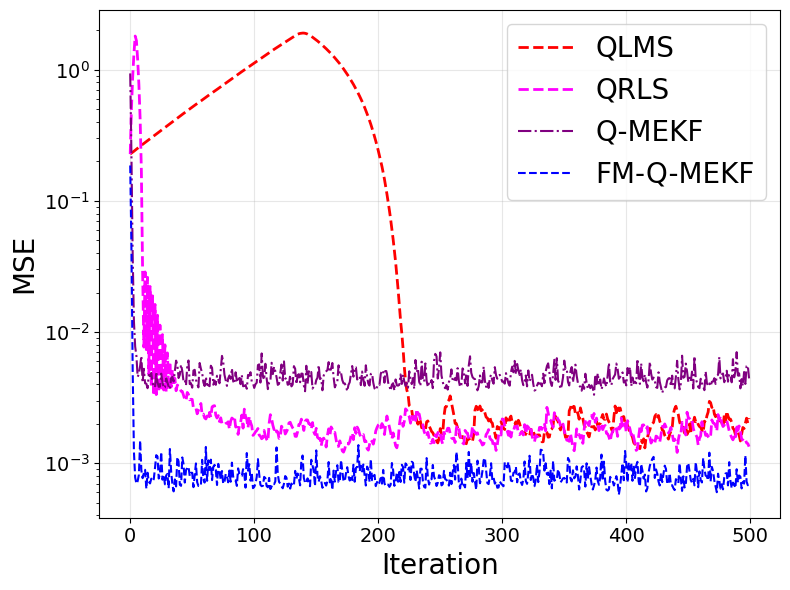

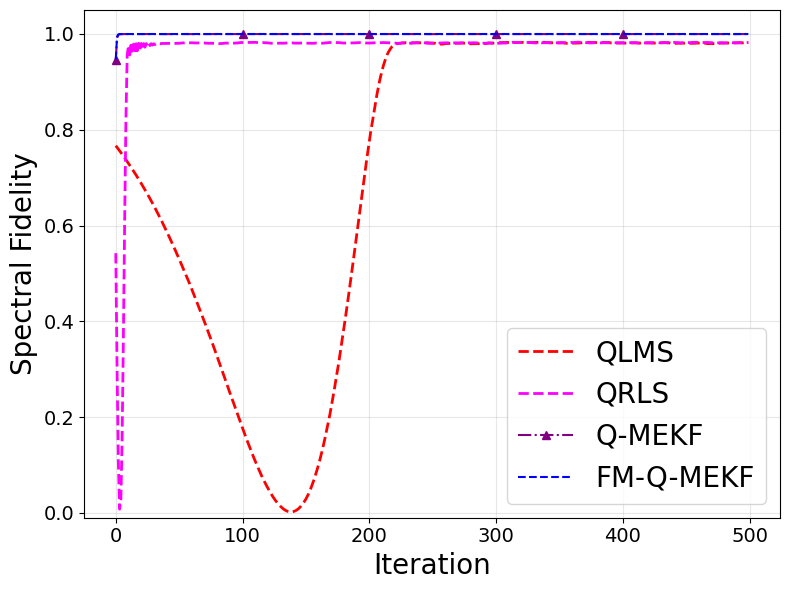

In [99]:
#==============================================================================
# Plotting
#==============================================================================
print("\n" + "="*80)
print("Generating plots...")
print("="*80)

alg_names = {
    'kalman_optimized': 'Q-MEKF',
    'kalman_fading': 'FM-Q-MEKF',
    'true_qlms': 'QLMS',
    'true_qrls': 'QRLS'
}

algorithms = ['true_qlms', 'true_qrls', 'kalman_optimized',
                'kalman_fading']

#fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Color scheme
colors = {
    'kalman_optimized': 'purple',
    'kalman_fading': 'blue',
    'true_qlms': 'red',
    'true_qrls': 'magenta'
}

linestyles = {
    'kalman_optimized': {'ls': '-.', 'marker': '^'},
    'kalman_fading': {'ls': '--', 'marker': ''},
    'true_qlms': {'ls': '--', 'marker': ''},
    'true_qrls': {'ls': '--', 'marker': ''}
}

def style_axes(ax):
    ax.tick_params(axis='both', labelsize=14) # Numerical values font
    ax.grid(True, alpha=0.3)

# --- (a) MSE Convergence ---
fig1, ax1 = plt.subplots(figsize=(8, 6))
for alg in algorithms:
    ax1.semilogy(stats[alg]['mse_mean'], 
                 label=alg_names[alg],
                 color=colors[alg],
                 linestyle=linestyles[alg]['ls'],
                 linewidth=2 if 'true' in alg else 1.5)

ax1.set_xlabel('Iteration', fontsize=20)
ax1.set_ylabel('MSE', fontsize=20)
ax1.legend(fontsize=20, loc='upper right')
style_axes(ax1)
fig1.tight_layout()
fig1.savefig('01_mse_spectral_fidelity.pdf', bbox_inches='tight')

# --- (b) Spectral Fidelity ---
fig2, ax2 = plt.subplots(figsize=(8, 6))
for alg in algorithms:
    ax2.plot(stats[alg]['fid_mean'],
             label=alg_names[alg],
             color=colors[alg],
             linestyle=linestyles[alg]['ls'],
             marker=linestyles[alg]['marker'],
             markevery=100, # Prevents marker crowding
             linewidth=2 if 'true' in alg else 1.5)

ax2.set_xlabel('Iteration', fontsize=20)
ax2.set_ylabel('Spectral Fidelity', fontsize=20)
ax2.set_ylim([-0.01, 1.05])
ax2.legend(fontsize=20, loc='lower right')
style_axes(ax2)
fig2.tight_layout()
fig2.savefig('02_spectral_fidelity.pdf', bbox_inches='tight')

In [50]:
#==============================================================================
# RE-LOCK TIME ANALYSIS AFTER STEP/BURST EVENTS
#==============================================================================
print("\n" + "="*80)
print("RE-LOCK TIME ANALYSIS")
print("="*80)

# Target algorithms for re-lock analysis
relock_algorithms = ['true_qlms', 'true_qrls', 'kalman_optimized', 'kalman_fading']

# Run multiple trials to collect re-lock statistics
relock_stats = {alg: {'times': [], 'counts': []} for alg in relock_algorithms}

print(f"\nMeasuring re-lock times for {len(relock_algorithms)} algorithms across {10} trials...")

for trial_idx in range(10):
    if (trial_idx + 1) % 2 == 0:
        print(f"  Trial {trial_idx + 1}/10")
    
    # Test each algorithm
    if 'true_qlms' in relock_algorithms:
        channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
        times, events = simulator.compute_relock_time(
            channel, 
            lambda ch: simulator.run_true_qlms(ch),
            mse_threshold=1e-3,
            event_detection_threshold=0.15
        )
        relock_stats['true_qlms']['times'].extend(times)
        relock_stats['true_qlms']['counts'].append(len(events))
    
    if 'true_qrls' in relock_algorithms:
        channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
        times, events = simulator.compute_relock_time(
            channel, 
            lambda ch: simulator.run_true_qrls(ch),
            mse_threshold=1e-3,
            event_detection_threshold=0.15
        )
        relock_stats['true_qrls']['times'].extend(times)
        relock_stats['true_qrls']['counts'].append(len(events))
    
    if 'true_meskf' in relock_algorithms:
        channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
        times, events = simulator.compute_relock_time(
            channel, 
            lambda ch: simulator.run_meskf(ch),
            mse_threshold=1e-3,
            event_detection_threshold=0.15
        )
        relock_stats['true_meskf']['times'].extend(times)
        relock_stats['true_meskf']['counts'].append(len(events))
    
    if 'kalman_optimized' in relock_algorithms:
        channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
        times, events = simulator.compute_relock_time(
            channel, 
            lambda ch: simulator.run_kalman_optimized(ch),
            mse_threshold=1e-3,
            event_detection_threshold=0.15
        )
        relock_stats['kalman_optimized']['times'].extend(times)
        relock_stats['kalman_optimized']['counts'].append(len(events))
    
    if 'kalman_fading' in relock_algorithms:
        channel = QuantumChannel(fiber_length_km=FIBER_LENGTH_KM)
        times, events = simulator.compute_relock_time(
            channel, 
            lambda ch: simulator.run_kalman_fading(ch),
            mse_threshold=1e-3,
            event_detection_threshold=0.15
        )
        relock_stats['kalman_fading']['times'].extend(times)
        relock_stats['kalman_fading']['counts'].append(len(events))

# Compute re-lock statistics
print("\n" + "="*80)
print("RE-LOCK TIME STATISTICS")
print("="*80)
print(f"\n{'Algorithm':<20} {'Avg Events/Run':<18} {'Mean Re-lock (iter)':<22} {'Median':<12} {'Std Dev':<12}")
print("-"*90)

relock_summary = {}
for alg in relock_algorithms:
    times = np.array(relock_stats[alg]['times'])
    counts = np.array(relock_stats[alg]['counts'])
    
    avg_events = np.mean(counts) if len(counts) > 0 else 0
    
    if len(times) > 0:
        mean_relock = np.mean(times)
        median_relock = np.median(times)
        std_relock = np.std(times)
    else:
        mean_relock = median_relock = std_relock = 0
    
    relock_summary[alg] = {
        'mean': mean_relock,
        'median': median_relock,
        'std': std_relock,
        'avg_events': avg_events,
        'times': times
    }
    
    print(f"{alg_names[alg]:<20} {avg_events:<18.1f} {mean_relock:<22.1f} {median_relock:<12.1f} {std_relock:<12.1f}")

print("\n" + "="*80)



RE-LOCK TIME ANALYSIS

Measuring re-lock times for 4 algorithms across 10 trials...


C:\Users\z642291\AppData\Local\Temp\ipykernel_40860\2443154606.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  total_mse += float(nu.T @ nu)
C:\Users\z642291\AppData\Local\Temp\ipykernel_40860\272454446.py:155: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  totalmse = float(nu.T @ nu)
C:\Users\z642291\AppData\Local\Temp\ipykernel_40860\272454446.py:161: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nisvals[f] = float((nu.T @ np.linalg.solve(S0, nu)) / 3.0)


  Trial 2/10
  Trial 4/10
  Trial 6/10
  Trial 8/10
  Trial 10/10

RE-LOCK TIME STATISTICS

Algorithm            Avg Events/Run     Mean Re-lock (iter)    Median       Std Dev     
------------------------------------------------------------------------------------------
QLMS                 94.4               4.9                    2.0          20.2        
QRLS                 152.0              2.0                    1.0          2.0         
Q-MEKF               155.0              4.4                    3.0          3.7         
FM-Q-MEKF            153.2              0.9                    1.0          1.0         




Generating and saving re-lock time visualizations...
Saved: average_relock_time.pdf
Saved: cumulative_relock_distribution.pdf

Re-lock time visualizations complete!


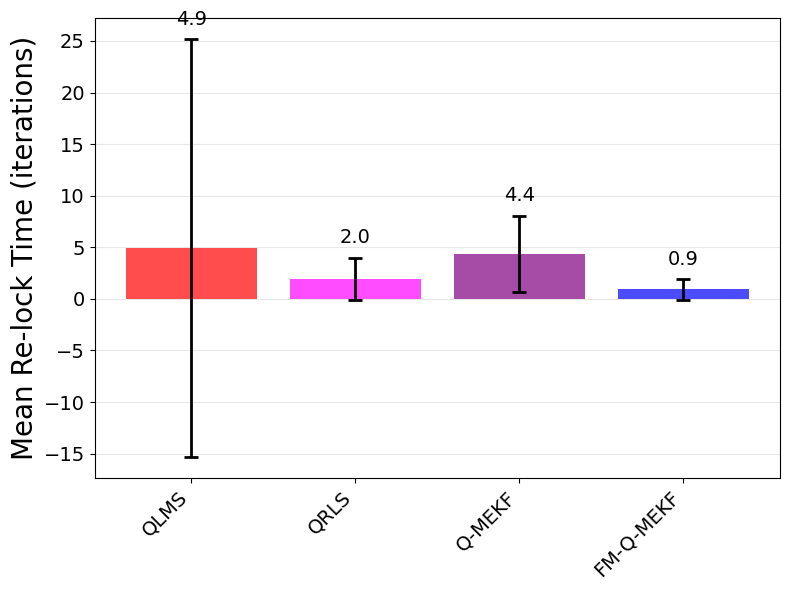

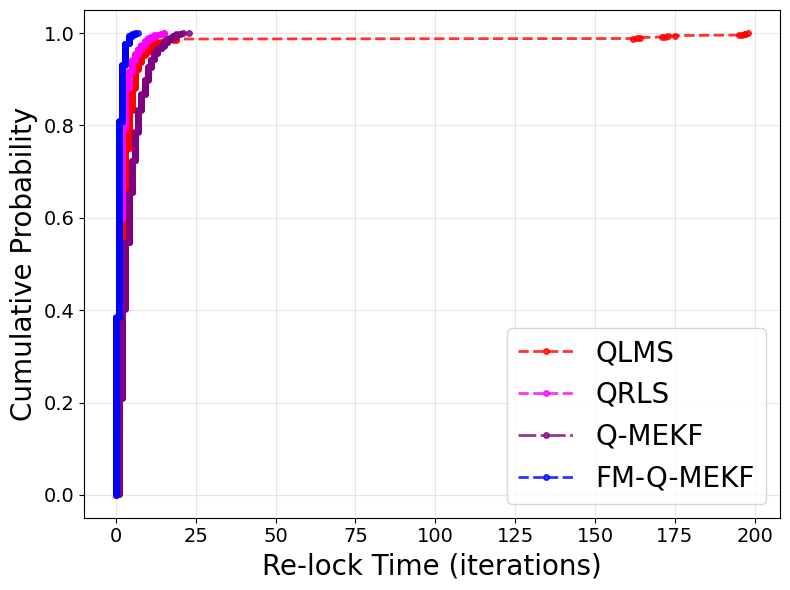

In [98]:
#==============================================================================
# RE-LOCK TIME VISUALIZATION (Separated and Saved as PDF)
#==============================================================================
print("\nGenerating and saving re-lock time visualizations...")
labels = [alg_names[alg] for alg in relock_algorithms]
# --- FIGURE 1: Mean re-lock times with error bars ---
fig1, ax1 = plt.subplots(figsize=(8, 6))

means = [relock_summary[alg]['mean'] for alg in relock_algorithms]
stds = [relock_summary[alg]['std'] for alg in relock_algorithms]
x_pos = np.arange(len(relock_algorithms))

bars = ax1.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7,
              color=[colors[alg] for alg in relock_algorithms],
              error_kw={'elinewidth': 2, 'capthick': 2})

ax1.set_ylabel('Mean Re-lock Time (iterations)', fontsize=20)
#ax1.set_title('Average Re-lock Time Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='both', which='major', labelsize=14)

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax1.text(i, mean + std + 1, f'{mean:.1f}', ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.savefig("03_average_relock_time.pdf", format='pdf', bbox_inches='tight')
print("Saved: average_relock_time.pdf")


# --- FIGURE 2: Cumulative distribution of re-lock times ---
fig2, ax2 = plt.subplots(figsize=(8, 6))

for alg in relock_algorithms:
    times_sorted = np.sort(relock_summary[alg]['times'])
    if len(times_sorted) > 0:
        cumulative = np.arange(1, len(times_sorted) + 1) / len(times_sorted)
        ax2.plot(times_sorted, cumulative, marker='o', markersize=4, label=alg_names[alg],
                color=colors[alg], linestyle=linestyles[alg]['ls'], linewidth=2, alpha=0.8)

ax2.set_xlabel('Re-lock Time (iterations)', fontsize=20)
ax2.set_ylabel('Cumulative Probability', fontsize=20)
#ax2.set_title('Cumulative Re-lock Time Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=20, loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.savefig("04_cumulative_relock_distribution.pdf", format='pdf', bbox_inches='tight')
print("Saved: cumulative_relock_distribution.pdf")

print("\nRe-lock time visualizations complete!")

# --- Detailed statistics table remains the same ---
# ... (your existing print logic for the table) ...

plt.show()

In [100]:
#==============================================================================
# OUTAGE PROBABILITY ANALYSIS
#==============================================================================
print("\n" + "="*80)
print("OUTAGE PROBABILITY ANALYSIS")
print("="*80)

# Define outage threshold (fidelity < 0.95 = outage)
FIDELITY_THRESHOLD = 0.99
OUTAGE_THRESHOLD = 1 - FIDELITY_THRESHOLD  # MSE threshold for outage

print(f"\nOutage Definition: Spectral Fidelity < {FIDELITY_THRESHOLD} (MSE > {OUTAGE_THRESHOLD:.3f})")

# ============================================================================
# PART 1: OUTAGE PROBABILITY vs FIBER LENGTH
# ============================================================================
print("\n" + "-"*80)
print("Part 1: Outage Probability vs Fiber Length")
print("-"*80)

fiber_lengths = [50, 100, 200, 400, 800, 1200]  # km
outage_vs_length = {alg: {'lengths': [], 'outage_probs': [], 'counts': []} 
                    for alg in relock_algorithms}

print(f"\nTesting {len(relock_algorithms)} algorithms across {len(fiber_lengths)} fiber lengths...")
print(f"Trials per length: 5")

for length_idx, fiber_len in enumerate(fiber_lengths):
    print(f"  Fiber length: {fiber_len} km ({length_idx+1}/{len(fiber_lengths)})")
    
    for alg in relock_algorithms:
        outage_count = 0
        total_runs = 5
        
        for run in range(total_runs):
            channel = QuantumChannel(fiber_length_km=fiber_len)
            
            if alg == 'true_qlms':
                _, _, fid = simulator.run_true_qlms(channel)
            elif alg == 'true_qrls':
                _, _, fid = simulator.run_true_qrls(channel)
            elif alg == 'true_meskf':
                _, _, fid = simulator.run_meskf(channel)
            elif alg == 'kalman_optimized':
                _, _, fid = simulator.run_kalman_optimized(channel)
            elif alg == 'kalman_fading':
                _, _, fid = simulator.run_kalman_fading(channel)
            
            # Check if in outage (fidelity < threshold for majority of iterations)
            time_in_outage = np.sum(fid < FIDELITY_THRESHOLD)
            outage_fraction = time_in_outage / len(fid)
            
            if outage_fraction > 0.1:  # More than 10% time in outage = outage event
                outage_count += 1
        
        outage_prob = outage_count / total_runs
        outage_vs_length[alg]['lengths'].append(fiber_len)
        outage_vs_length[alg]['outage_probs'].append(outage_prob)
        outage_vs_length[alg]['counts'].append(outage_count)

print("\nFiber length outage analysis complete!")

# ============================================================================
# PART 2: OUTAGE PROBABILITY vs DRIFT/BURST STRENGTH
# ============================================================================
print("\n" + "-"*80)
print("Part 2: Outage Probability vs Drift/Burst Strength")
print("-"*80)

# Vary drift_gamma (controls temporal PMD drift)
drift_gammas = [0.001, 0.005, 0.01, 0.02, 0.03, 0.04,0.05]
outage_vs_drift = {alg: {'drift_gammas': [], 'outage_probs': [], 'counts': []} 
                   for alg in relock_algorithms}

print(f"\nTesting {len(relock_algorithms)} algorithms across {len(drift_gammas)} drift strengths...")
print(f"Trials per strength: 5")

for drift_idx, drift_gamma in enumerate(drift_gammas):
    print(f"  Drift gamma: {drift_gamma} ({drift_idx+1}/{len(drift_gammas)})")
    
    for alg in relock_algorithms:
        outage_count = 0
        total_runs = 5
        
        for run in range(total_runs):
            channel = QuantumChannel(
                fiber_length_km=FIBER_LENGTH_KM,
                drift_gamma=drift_gamma  # Vary drift strength
            )
            
            if alg == 'true_qlms':
                _, _, fid = simulator.run_true_qlms(channel)
            elif alg == 'true_qrls':
                _, _, fid = simulator.run_true_qrls(channel)
            elif alg == 'true_meskf':
                _, _, fid = simulator.run_meskf(channel)
            elif alg == 'kalman_optimized':
                _, _, fid = simulator.run_kalman_optimized(channel)
            elif alg == 'kalman_fading':
                _, _, fid = simulator.run_kalman_fading(channel)
            
            # Check if in outage
            time_in_outage = np.sum(fid < FIDELITY_THRESHOLD)
            outage_fraction = time_in_outage / len(fid)
            
            if outage_fraction > 0.1:
                outage_count += 1
        
        outage_prob = outage_count / total_runs
        outage_vs_drift[alg]['drift_gammas'].append(drift_gamma)
        outage_vs_drift[alg]['outage_probs'].append(outage_prob)
        outage_vs_drift[alg]['counts'].append(outage_count)

print("\nDrift strength outage analysis complete!")

print("\n" + "="*80)



OUTAGE PROBABILITY ANALYSIS

Outage Definition: Spectral Fidelity < 0.99 (MSE > 0.010)

--------------------------------------------------------------------------------
Part 1: Outage Probability vs Fiber Length
--------------------------------------------------------------------------------

Testing 4 algorithms across 6 fiber lengths...
Trials per length: 5
  Fiber length: 50 km (1/6)


C:\Users\z642291\AppData\Local\Temp\ipykernel_40860\2443154606.py:107: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  total_mse += float(nu.T @ nu)
C:\Users\z642291\AppData\Local\Temp\ipykernel_40860\272454446.py:155: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  totalmse = float(nu.T @ nu)
C:\Users\z642291\AppData\Local\Temp\ipykernel_40860\272454446.py:161: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nisvals[f] = float((nu.T @ np.linalg.solve(S0, nu)) / 3.0)


  Fiber length: 100 km (2/6)
  Fiber length: 200 km (3/6)
  Fiber length: 400 km (4/6)
  Fiber length: 800 km (5/6)
  Fiber length: 1200 km (6/6)

Fiber length outage analysis complete!

--------------------------------------------------------------------------------
Part 2: Outage Probability vs Drift/Burst Strength
--------------------------------------------------------------------------------

Testing 4 algorithms across 7 drift strengths...
Trials per strength: 5
  Drift gamma: 0.001 (1/7)
  Drift gamma: 0.005 (2/7)
  Drift gamma: 0.01 (3/7)
  Drift gamma: 0.02 (4/7)
  Drift gamma: 0.03 (5/7)
  Drift gamma: 0.04 (6/7)
  Drift gamma: 0.05 (7/7)

Drift strength outage analysis complete!



Generating outage probability visualization...
Outage probability visualization complete!


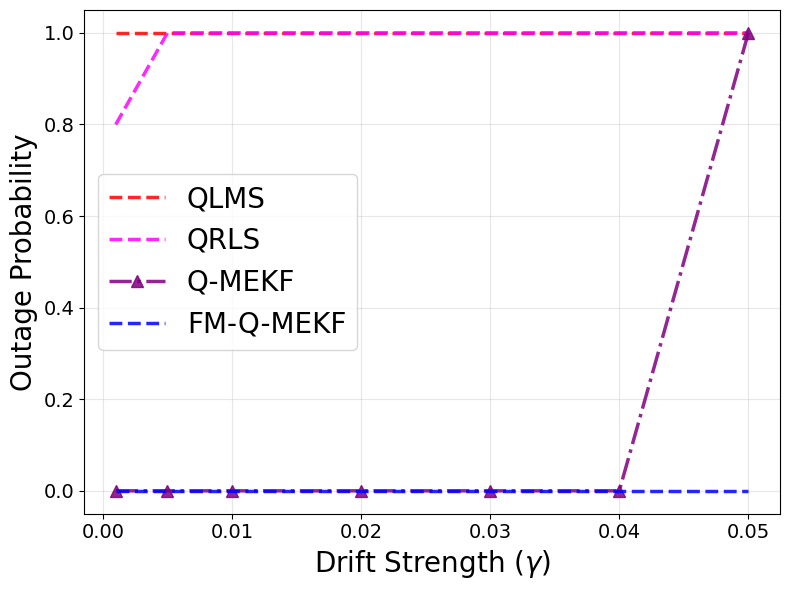

In [107]:
#==============================================================================
# OUTAGE PROBABILITY VISUALIZATION
#==============================================================================
print("Generating outage probability visualization...")

#fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig, ax = plt.subplots(figsize=(8, 6)) # Reduced size for clarity

# (b) Outage Probability vs Drift Strength
#ax = axs[0]
for alg in relock_algorithms:
    drift_gammas = outage_vs_drift[alg]['drift_gammas']
    probs = outage_vs_drift[alg]['outage_probs']
    
    ax.plot(drift_gammas, probs, markersize=8, label=alg_names[alg],
            color=colors[alg], linestyle=linestyles[alg]['ls'], marker=linestyles[alg]['marker'], linewidth=2.5, alpha=0.85)

ax.set_xlabel('Drift Strength ($\gamma$)', fontsize=20)
ax.set_ylabel('Outage Probability', fontsize=20)
#ax.set_title(f'(a) Outage Probability vs Drift Strength\n(Threshold: Fidelity < {FIDELITY_THRESHOLD})', y=-0.3, 
#             fontsize=12, fontweight='bold')
ax.legend(fontsize=20, loc='center left', bbox_to_anchor=(0, 0.5))
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_ylim([-0.05, 1.05])

# # (d) Heatmap: Outage Probability vs Drift Strength (per algorithm)
# ax = axs[1]
# drift_array = np.array(outage_vs_drift[relock_algorithms[0]]['drift_gammas'])
# outage_matrix_drift = np.array([outage_vs_drift[alg]['outage_probs'] for alg in relock_algorithms])

# im = ax.imshow(outage_matrix_drift, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
# ax.set_xticks(np.arange(len(drift_array)))
# ax.set_yticks(np.arange(len(relock_algorithms)))
# ax.set_xticklabels([f'{γ:.3f}' for γ in drift_array], rotation=45)
# ax.set_yticklabels([alg_names[alg] for alg in relock_algorithms])

# ax.set_xlabel('Drift Strength ($\gamma$)', fontsize=22)
# ax.tick_params(axis='both', which='major', labelsize=14)

# #ax.set_title('(b) Outage Heatmap: Drift Strength', y=-0.3 , fontsize=12, fontweight='bold')

# # Add text annotations
# for i in range(len(relock_algorithms)):
#     for j in range(len(drift_array)):
#         text = ax.text(j, i, f'{outage_matrix_drift[i, j]:.2f}',
#                       ha="center", va="center", color="black", fontsize=9, fontweight='bold')

# plt.colorbar(im, ax=ax, label='Outage Probability')

plt.tight_layout()
plt.savefig('05_Outage_99.pdf', dpi=300)
print("Outage probability visualization complete!")